<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/Analytics/InitialBoundaryValueProblems/01_half_space_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-Switched Half-Space — Electric Field

## Problem formulation

A monochromatic plane wave propagates in an initially homogeneous, nondispersive dielectric medium with refractive index \(n_1\):

$$
\mathbf{e}_0(z,t)=E_0e^{i\omega_1t}e^{-ik_1z}\,\mathbf{x},
$$

where

$$
k_1=\frac{n_1\omega_1}{c}.
$$

At \(t=0\), the refractive index changes instantaneously only in the half-space \(z\ge0\):

$$
n(z)=
\begin{cases}
n_1, & z<0,\\
n_2, & z\ge0.
\end{cases}
$$

## Wave equations

For \(t>0\),

$$
\frac{\partial^2e_1}{\partial z^2}
-
\frac{n_1^2}{c^2}\frac{\partial^2e_1}{\partial t^2}
=0,
\qquad z<0,
$$

and

$$
\frac{\partial^2e_2}{\partial z^2}
-
\frac{n_2^2}{c^2}\frac{\partial^2e_2}{\partial t^2}
=0,
\qquad z\ge0.
$$

## Laplace transform

We apply the Laplace transform with respect to time:

$$
E_j(z,p)=\mathcal{L}\{e_j(z,t)\}
=
\int_0^\infty e_j(z,t)e^{-pt}\,dt,
$$

with

$$
\mathcal{L}\left\{\frac{\partial^2e_j}{\partial t^2}\right\}
=
p^2E_j(z,p)-p\,e_j(z,0)-\dot e_j(z,0).
$$

## Initial conditions

For $z<0$,

$$
e_1(z,0)=E_0e^{-ik_1z},
\qquad
\dot e_1(z,0)=i\omega_1E_0e^{-ik_1z}.
$$

For $z\ge0$,

$$
e_2(z,0)=\frac{n_1^2}{n_2^2}E_0e^{-ik_1z},
$$

$$
\dot e_2(z,0)
=
i\omega_1\frac{n_1^2}{n_2^2}E_0e^{-ik_1z}.
$$

## Laplace-domain solution

The transformed fields are

$$
E_1(z,p)
=
C_1(p)e^{n_1pz/c}
+
\frac{E_0}{p-i\omega_1}e^{-ik_1z},
\qquad z<0,
$$

and

$$
E_2(z,p)
=
C_2(p)e^{-n_2pz/c}
+
\frac{n_1^2}{n_2^2}
\frac{p+i\omega_1}{p^2+\omega_2^2}
E_0e^{-ik_1z},
\qquad z\ge0,
$$

where

$$
\omega_2=\frac{n_1}{n_2}\omega_1.
$$

## Boundary conditions and coefficients

At \(z=0\),

$$
E_1(-0,p)=E_2(+0,p),
$$

$$
\left.\frac{\partial E_1}{\partial z}\right|_{z=-0}
=
\left.\frac{\partial E_2}{\partial z}\right|_{z=+0}.
$$

The resulting coefficients are

$$
C_1(p)
=
E_0\frac{n_1-n_2}{n_2}
\frac{p}{(p-i\omega_1)(p+i\omega_2)},
$$

$$
C_2(p)
=
E_0\frac{n_1(n_2-n_1)}{n_2^2}
\frac{p(p+i\omega_1)}
{(p-i\omega_1)(p^2+\omega_2^2)}.
$$

## Time-domain solution

Let $\Theta(\cdot)$ denote the Heaviside step function.

For $z<0$,

$$
\begin{aligned}
e_1(z,t)
={}&E_0e^{i\omega_1t-ik_1z}
\\
&+\Theta\left(t+\frac{n_1z}{c}\right)
E_0\frac{n_1-n_2}{n_1+n_2}
e^{i\omega_1\left(t+\frac{n_1z}{c}\right)}
\\
&+\Theta\left(t+\frac{n_1z}{c}\right)
E_0\frac{n_1(n_1-n_2)}
{n_2(n_1+n_2)}
e^{-i\omega_2\left(t+\frac{n_1z}{c}\right)}.
\end{aligned}
$$

For $z\ge0$,

$$
\begin{aligned}
e_2(z,t)
={}&
E_0\frac{n_1(n_1+n_2)}{2n_2^2}
e^{i\omega_2t-ik_1z}
+
E_0\frac{n_1(n_1-n_2)}{2n_2^2}
e^{-i\omega_2t-ik_1z}
\\
&+
\Theta\left(t-\frac{n_2z}{c}\right)
E_0\frac{2n_1}{n_1+n_2}
e^{i\omega_1\left(t-\frac{n_2z}{c}\right)}
\\
&-
\Theta\left(t-\frac{n_2z}{c}\right)
E_0\frac{n_1(n_1+n_2)}{2n_2^2}
e^{i\omega_2\left(t-\frac{n_2z}{c}\right)}
\\
&-
\Theta\left(t-\frac{n_2z}{c}\right)
E_0\frac{n_1(n_1-n_2)^2}
{2n_2^2(n_1+n_2)}
e^{-i\omega_2\left(t-\frac{n_2z}{c}\right)}.
\end{aligned}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Python implementation

In [ ]:
def heaviside(x):
    return np.heaviside(x, 1.0)


def half_space_E_analytics(z, t, n1, n2, w1, E0=1.0, c=1.0):

    z = np.asarray(z)
    t = np.asarray(t)

    w2 = n1 / n2 * w1
    k1 = n1 * w1 / c

    tau_left = t + n1 * z / c
    tau_right = t - n2 * z / c

    e_left = (
        E0 * np.exp(1j * w1 * t - 1j * k1 * z)
        + heaviside(tau_left)
        * E0 * (n1 - n2) / (n1 + n2)
        * np.exp(1j * w1 * tau_left)
        + heaviside(tau_left)
        * E0 * n1 * (n1 - n2) / (n2 * (n1 + n2))
        * np.exp(-1j * w2 * tau_left)
    )

    e_right = (
        E0 * n1 * (n1 + n2) / (2 * n2**2)
        * np.exp(1j * w2 * t - 1j * k1 * z)
        + E0 * n1 * (n1 - n2) / (2 * n2**2)
        * np.exp(-1j * w2 * t - 1j * k1 * z)
        + heaviside(tau_right)
        * E0 * 2 * n1 / (n1 + n2)
        * np.exp(1j * w1 * tau_right)
        - heaviside(tau_right)
        * E0 * n1 * (n1 + n2) / (2 * n2**2)
        * np.exp(1j * w2 * tau_right)
        - heaviside(tau_right)
        * E0 * n1 * (n1 - n2)**2
        / (2 * n2**2 * (n1 + n2))
        * np.exp(-1j * w2 * tau_right)
    )

    return np.where(z < 0, e_left, e_right)

## Parameters and normalization

We use

$$
\omega_1=2\pi,
$$

so

$$
T_{\mathrm{ref}}
=
\frac{2\pi}{\omega_1}
=
1.
$$

The incident wavelength is

$$
\lambda_1
=
\frac{2\pi}{k_1}
=
\frac{2\pi c}{n_1\omega_1}.
$$

Time and space are displayed as $t/T_{\mathrm{ref}}$ and $z/\lambda_1$.

In [ ]:
n1 = 1.5
n2 = 1.0
w1 = 2 * np.pi
E0 = 1.0
c = 1.0

T_ref = 2 * np.pi / w1
k1 = n1 * w1 / c
lambda1 = 2 * np.pi / k1

print(f"T_ref   = {T_ref:.6f}")
print(f"lambda1 = {lambda1:.6f}")

T_ref   = 1.000000
lambda1 = 0.666667


## Temporal traces at fixed positions

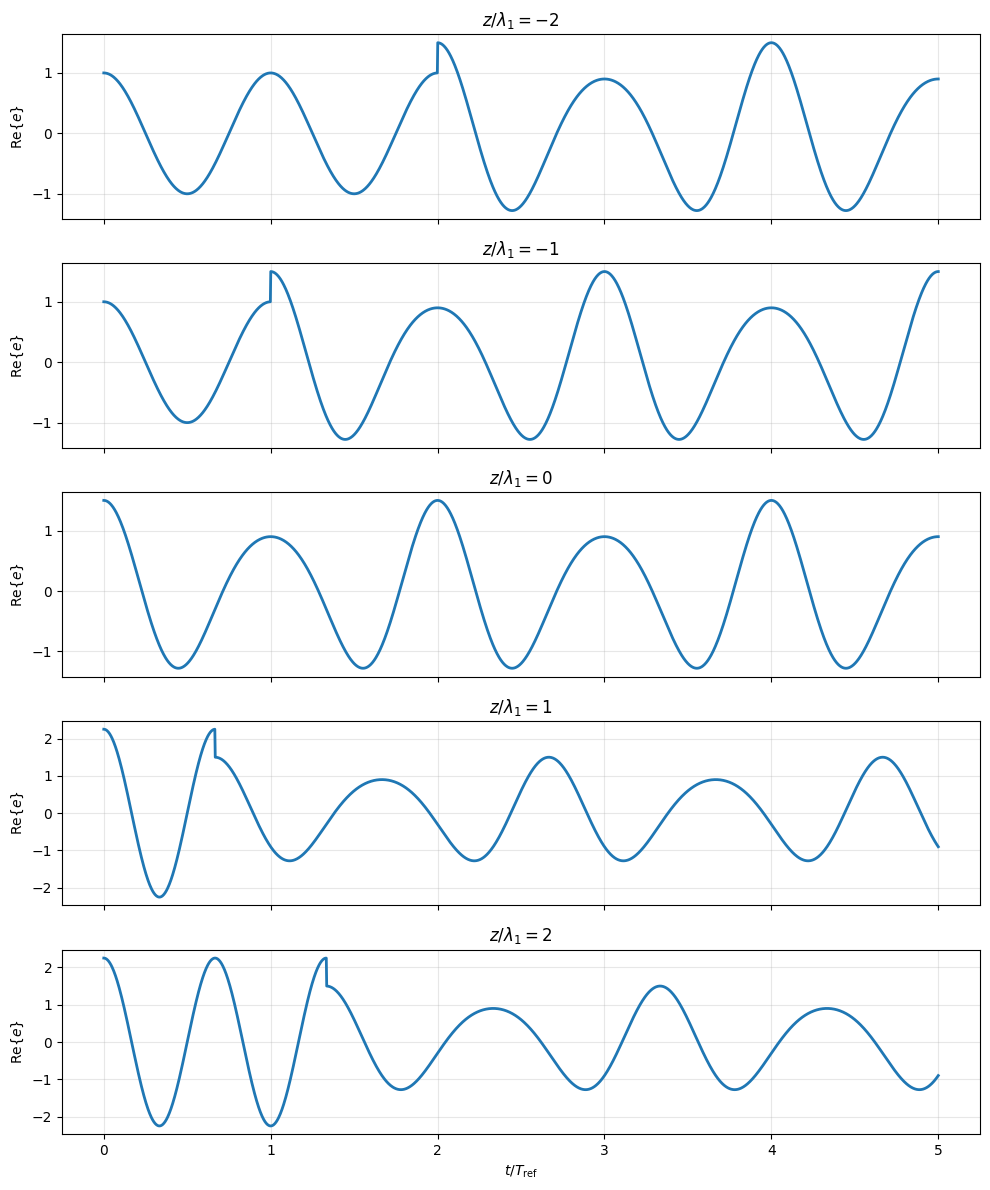

In [ ]:
zeta_values = [-2, -1, 0, 1, 2]
t_norm = np.linspace(0, 5, 2000)
t = t_norm * T_ref

fig, axes = plt.subplots(len(zeta_values), 1, figsize=(10, 12), sharex=True)

for ax, zeta in zip(axes, zeta_values):
    z = zeta * lambda1
    e = half_space_E_analytics(z, t, n1, n2, w1, E0, c)

    ax.plot(t_norm, np.real(e), lw=2)
    ax.set_ylabel(r"$\mathrm{Re}\{e\}$")
    ax.set_title(rf"$z/\lambda_1={zeta}$")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(r"$t/T_{\mathrm{ref}}$")

plt.tight_layout()
plt.show()

## Space-time field map

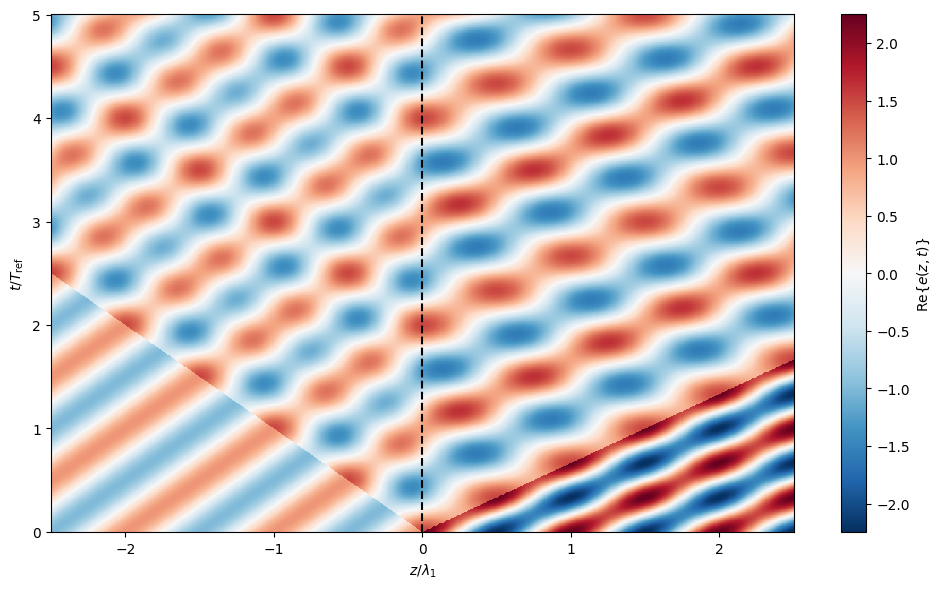

In [ ]:
zeta = np.linspace(-2.5, 2.5, 700)
t_norm = np.linspace(0, 5, 700)

ZETA, T_NORM = np.meshgrid(zeta, t_norm)
Z = ZETA * lambda1
T = T_NORM * T_ref

E = half_space_E_analytics(Z, T, n1, n2, w1, E0, c)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ZETA, T_NORM, np.real(E), shading="auto", cmap="RdBu_r")
plt.axvline(0, color="black", ls="--", lw=1.5)
plt.colorbar(label=r"$\mathrm{Re}\{e(z,t)\}$")
plt.xlabel(r"$z/\lambda_1$")
plt.ylabel(r"$t/T_{\mathrm{ref}}$")
plt.tight_layout()
plt.show()

## Spatial profiles at fixed times

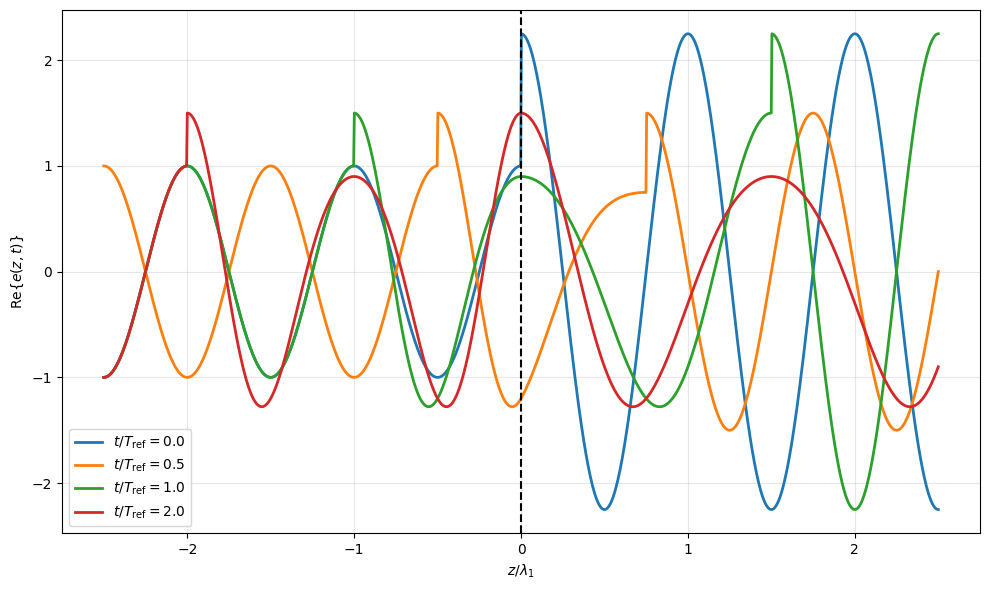

In [ ]:
zeta = np.linspace(-2.5, 2.5, 1200)
z = zeta * lambda1

time_values = [0.0, 0.5, 1.0, 2.0]

plt.figure(figsize=(10, 6))

for t_norm_value in time_values:
    t_value = t_norm_value * T_ref
    e = half_space_E_analytics(z, t_value, n1, n2, w1, E0, c)

    plt.plot(
        zeta,
        np.real(e),
        lw=2,
        label=rf"$t/T_{{\mathrm{{ref}}}}={t_norm_value}$"
    )

plt.axvline(0, color="black", ls="--", lw=1.5)
plt.xlabel(r"$z/\lambda_1$")
plt.ylabel(r"$\mathrm{Re}\{e(z,t)\}$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

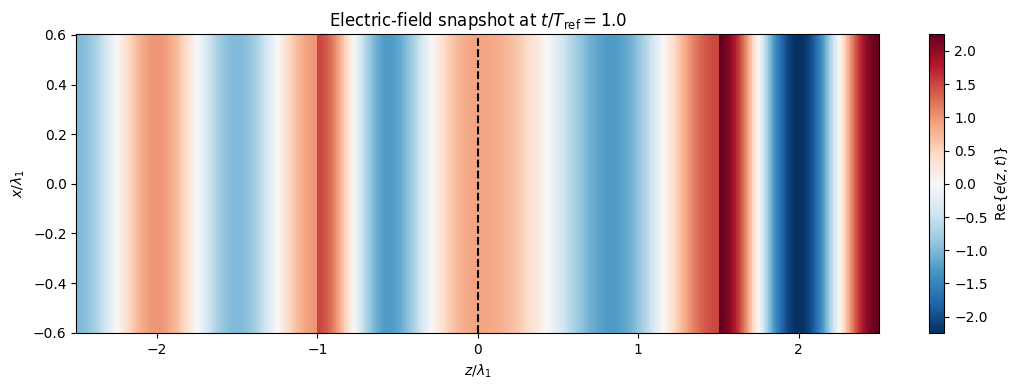

In [ ]:
# 2D snapshot of the electric field at a fixed time

t_snapshot_norm = 1.0
t_snapshot = t_snapshot_norm * T_ref

zeta = np.linspace(-2.5, 2.5, 1000)
xeta = np.linspace(-0.6, 0.6, 250)

ZETA, XETA = np.meshgrid(zeta, xeta)

Z = ZETA * lambda1

E_snapshot = half_space_E_analytics(
    Z,
    t_snapshot,
    n1,
    n2,
    w1,
    E0,
    c
)

plt.figure(figsize=(11, 4))

plt.pcolormesh(
    ZETA,
    XETA,
    np.real(E_snapshot),
    shading="auto",
    cmap="RdBu_r"
)

plt.axvline(0, color="black", ls="--", lw=1.5)

plt.colorbar(label=r"$\mathrm{Re}\{e(z,t)\}$")

plt.xlabel(r"$z/\lambda_1$")
plt.ylabel(r"$x/\lambda_1$")

plt.title(
    rf"Electric-field snapshot at "
    rf"$t/T_{{\mathrm{{ref}}}}={t_snapshot_norm}$"
)

plt.tight_layout()
plt.show()